   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

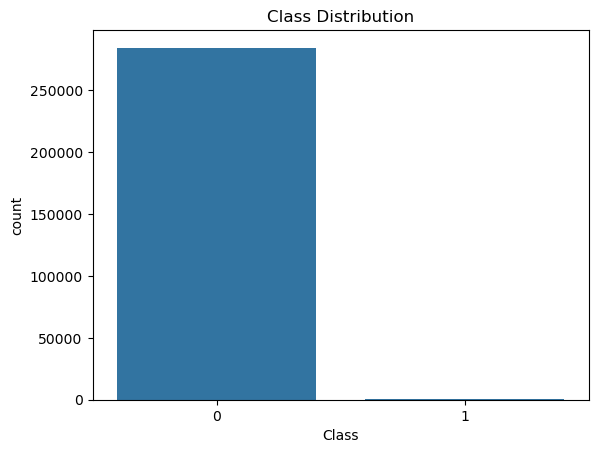

In [75]:
import arff  # pip install liac-arff
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных (ARFF)
with open("../data/raw/dataset", "r", encoding="utf-8") as f:
    obj = arff.load(f)

columns = [name for name, _ in obj["attributes"]]
df = pd.DataFrame(obj["data"], columns=columns)

print(df.head())

# Проверка дисбаланса классов
print(df['Class'].value_counts(normalize=True))

# Распределение классов
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

In [76]:
import numpy as np

# Простые проверки
print("shape:", df.shape)
print("na_rate(max):", float(df.isna().mean().max()))
print(df[["Time", "Amount", "Class"]].describe().T)

feature_cols = [c for c in df.columns if c != "Class"]

# Доп. фича для удобного просмотра хвоста сумм
if "Amount" in df.columns:
    df["Amount_log1p"] = np.log1p(df["Amount"])

shape: (284807, 31)
na_rate(max): 0.0
           count          mean           std  min      25%      50%  \
Time    284807.0  94813.859575  47488.145955  0.0  54201.5  84692.0   
Amount  284807.0     88.349619    250.120109  0.0      5.6     22.0   
Class   284807.0      0.001727      0.041527  0.0      0.0      0.0   

               75%        max  
Time    139320.500  172792.00  
Amount      77.165   25691.16  
Class        0.000       1.00  


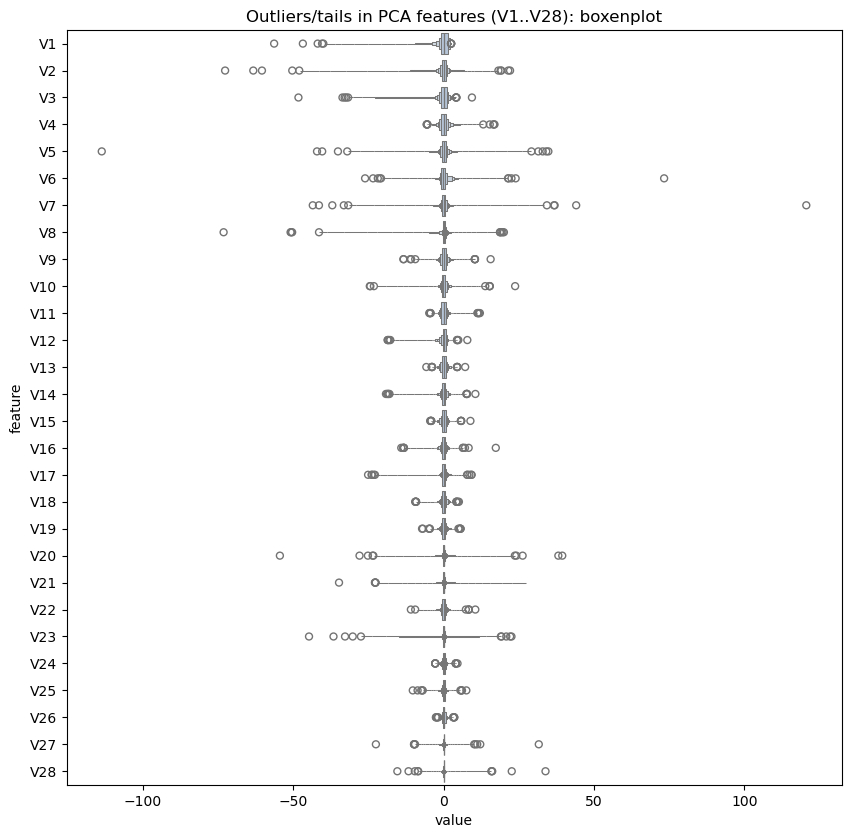

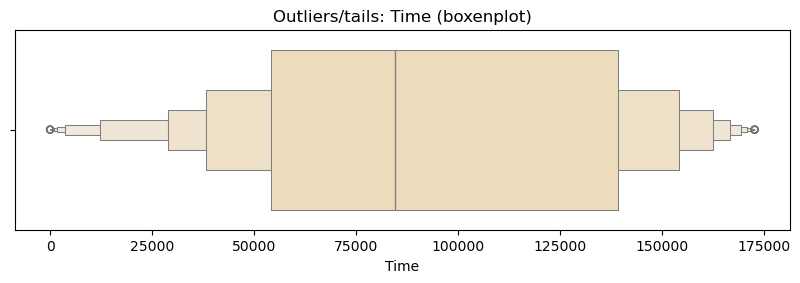

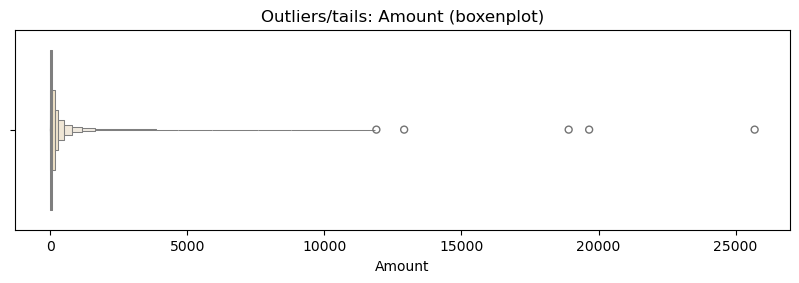

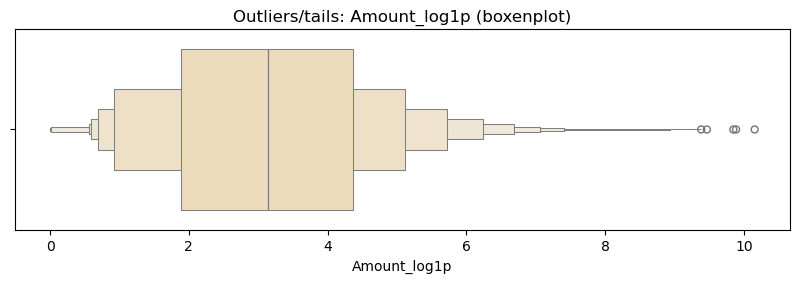

In [77]:
# 1) Выбросы

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_features = [c for c in df.columns if c != "Class"]
X_all = df[all_features].apply(pd.to_numeric, errors="coerce")

# Визуализация: V1..V28 вместе (они примерно в одной шкале), Time/Amount отдельно
v_cols = [c for c in all_features if c.startswith("V")]
other_cols = [c for c in ["Time", "Amount", "Amount_log1p"] if c in X_all.columns]

if v_cols:
    long_v = X_all[v_cols].melt(var_name="feature", value_name="value").dropna()
    plt.figure(figsize=(10, max(8, 0.35 * len(v_cols))))
    sns.boxenplot(data=long_v, x="value", y="feature", orient="h", color="lightsteelblue")
    plt.title("Outliers/tails in PCA features (V1..V28): boxenplot")
    plt.show()

if other_cols:
    for col in other_cols:
        x = X_all[col].dropna()
        plt.figure(figsize=(10, 2.6))
        sns.boxenplot(x=x, orient="h", color="wheat")
        plt.title(f"Outliers/tails: {col} (boxenplot)")
        plt.xlabel(col)
        plt.show()

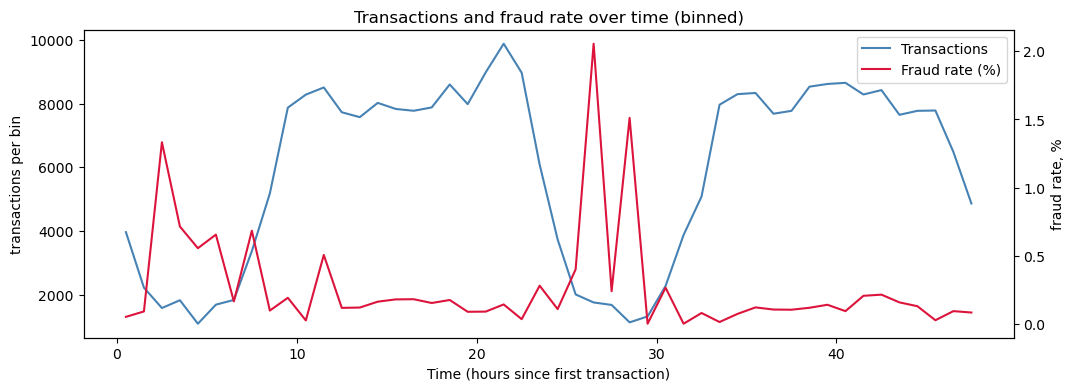

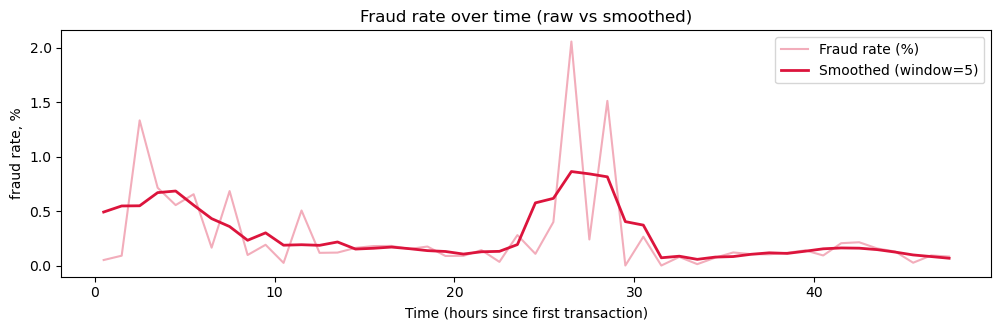

In [78]:
# 2) Time EDA: объём транзакций и fraud-rate во времени (по бинам)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Time задан в секундах от первой транзакции -> переведём в часы
if "Time_hours" not in df.columns:
    df["Time_hours"] = df["Time"] / 3600.0

n_bins = 48  # ~2 дня по 1 часу
bins = np.linspace(df["Time_hours"].min(), df["Time_hours"].max(), n_bins + 1)

tmp = df[["Time_hours", "Class"]].copy()
tmp["time_bin"] = pd.cut(tmp["Time_hours"], bins=bins, include_lowest=True)

agg = (
    tmp.groupby("time_bin", observed=True)["Class"]
    .agg(n_tx="count", n_fraud="sum")
    .assign(fraud_rate=lambda x: x["n_fraud"] / x["n_tx"])
)

centers = agg.index.map(lambda iv: iv.mid)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(centers, agg["n_tx"], color="steelblue", linewidth=1.5, label="Transactions")
ax1.set_xlabel("Time (hours since first transaction)")
ax1.set_ylabel("transactions per bin")

ax2 = ax1.twinx()
ax2.plot(centers, agg["fraud_rate"] * 100, color="crimson", linewidth=1.5, label="Fraud rate (%)")
ax2.set_ylabel("fraud rate, %")

# Легенда
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Transactions and fraud rate over time (binned)")
plt.show()

# Небольшое сглаживание fraud-rate (скользящее среднее по бинам)
window = 5
fraud_rate_smooth = agg["fraud_rate"].rolling(window=window, center=True, min_periods=1).mean()
plt.figure(figsize=(12, 3.2))
plt.plot(centers, agg["fraud_rate"] * 100, color="crimson", alpha=0.35, label="Fraud rate (%)")
plt.plot(centers, fraud_rate_smooth * 100, color="crimson", linewidth=2, label=f"Smoothed (window={window})")
plt.xlabel("Time (hours since first transaction)")
plt.ylabel("fraud rate, %")
plt.title("Fraud rate over time (raw vs smoothed)")
plt.legend()
plt.show()

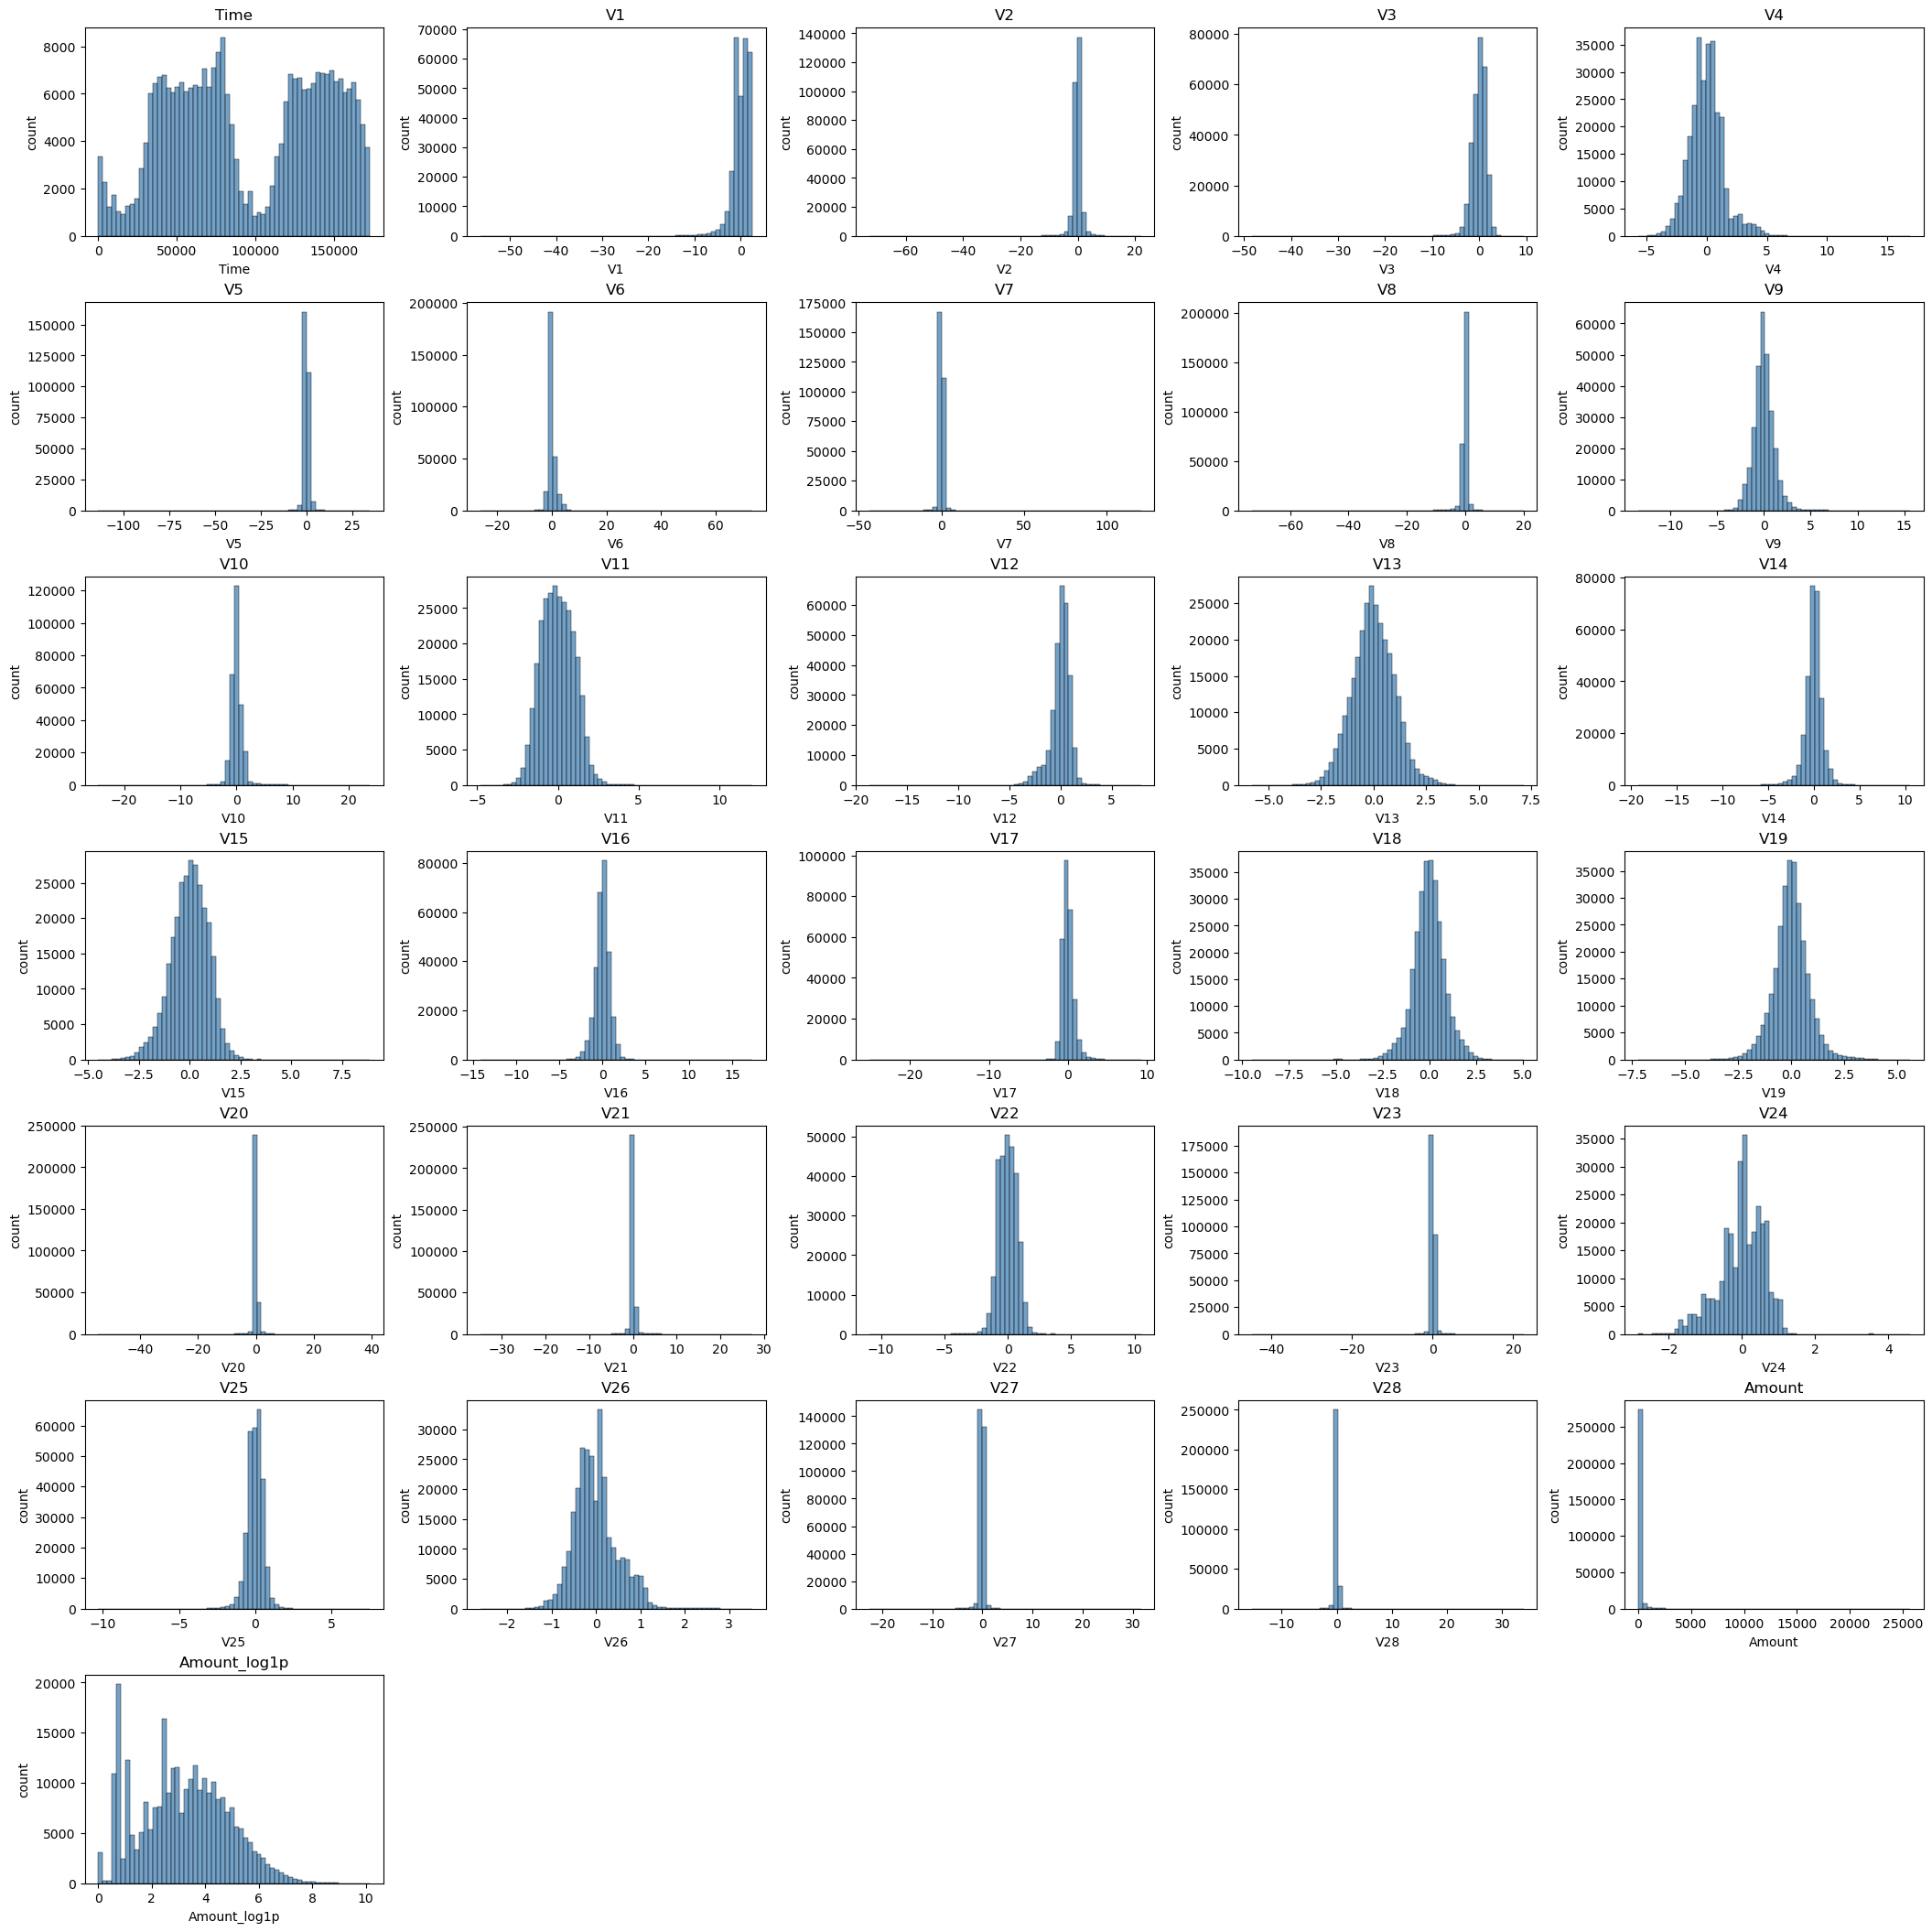

In [67]:
# 3) Распределение каждого признака

cols = feature_cols.copy()

# Если добавили Amount_log1p — покажем его тоже, но оригинальный Amount оставляем
if "Amount_log1p" in df.columns and "Amount_log1p" not in cols:
    cols.append("Amount_log1p")

n_cols = 5
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.0), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    sns.histplot(df[col], bins=60, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_ylabel("count")

for ax in axes[len(cols):]:
    ax.axis("off")

plt.show()

Top features by AUC/KS


,feature,auc,ks
14,V14,0.949160,0.842839
4,V4,0.938258,0.766404
12,V12,0.937040,0.783908
11,V11,0.918083,0.756067
10,V10,0.914057,0.804291
3,V3,0.912073,0.703682
2,V2,0.854955,0.633201
16,V16,0.847131,0.686506
9,V9,0.844090,0.576320
7,V7,0.835812,0.660578


Top features (final ranking; MI present if computed)


,feature,auc,ks,mi_approx
0,V14,0.949160,0.842839,0.038579
1,V4,0.938258,0.766404,0.024832
2,V12,0.937040,0.783908,0.034494
3,V11,0.918083,0.756067,0.031936
4,V10,0.914057,0.804291,0.035426
5,V3,0.912073,0.703682,0.025392
6,V2,0.854955,0.633201,0.016429
7,V16,0.847131,0.686506,0.028382
8,V9,0.844090,0.576320,0.019932
9,V7,0.835812,0.660578,0.020461


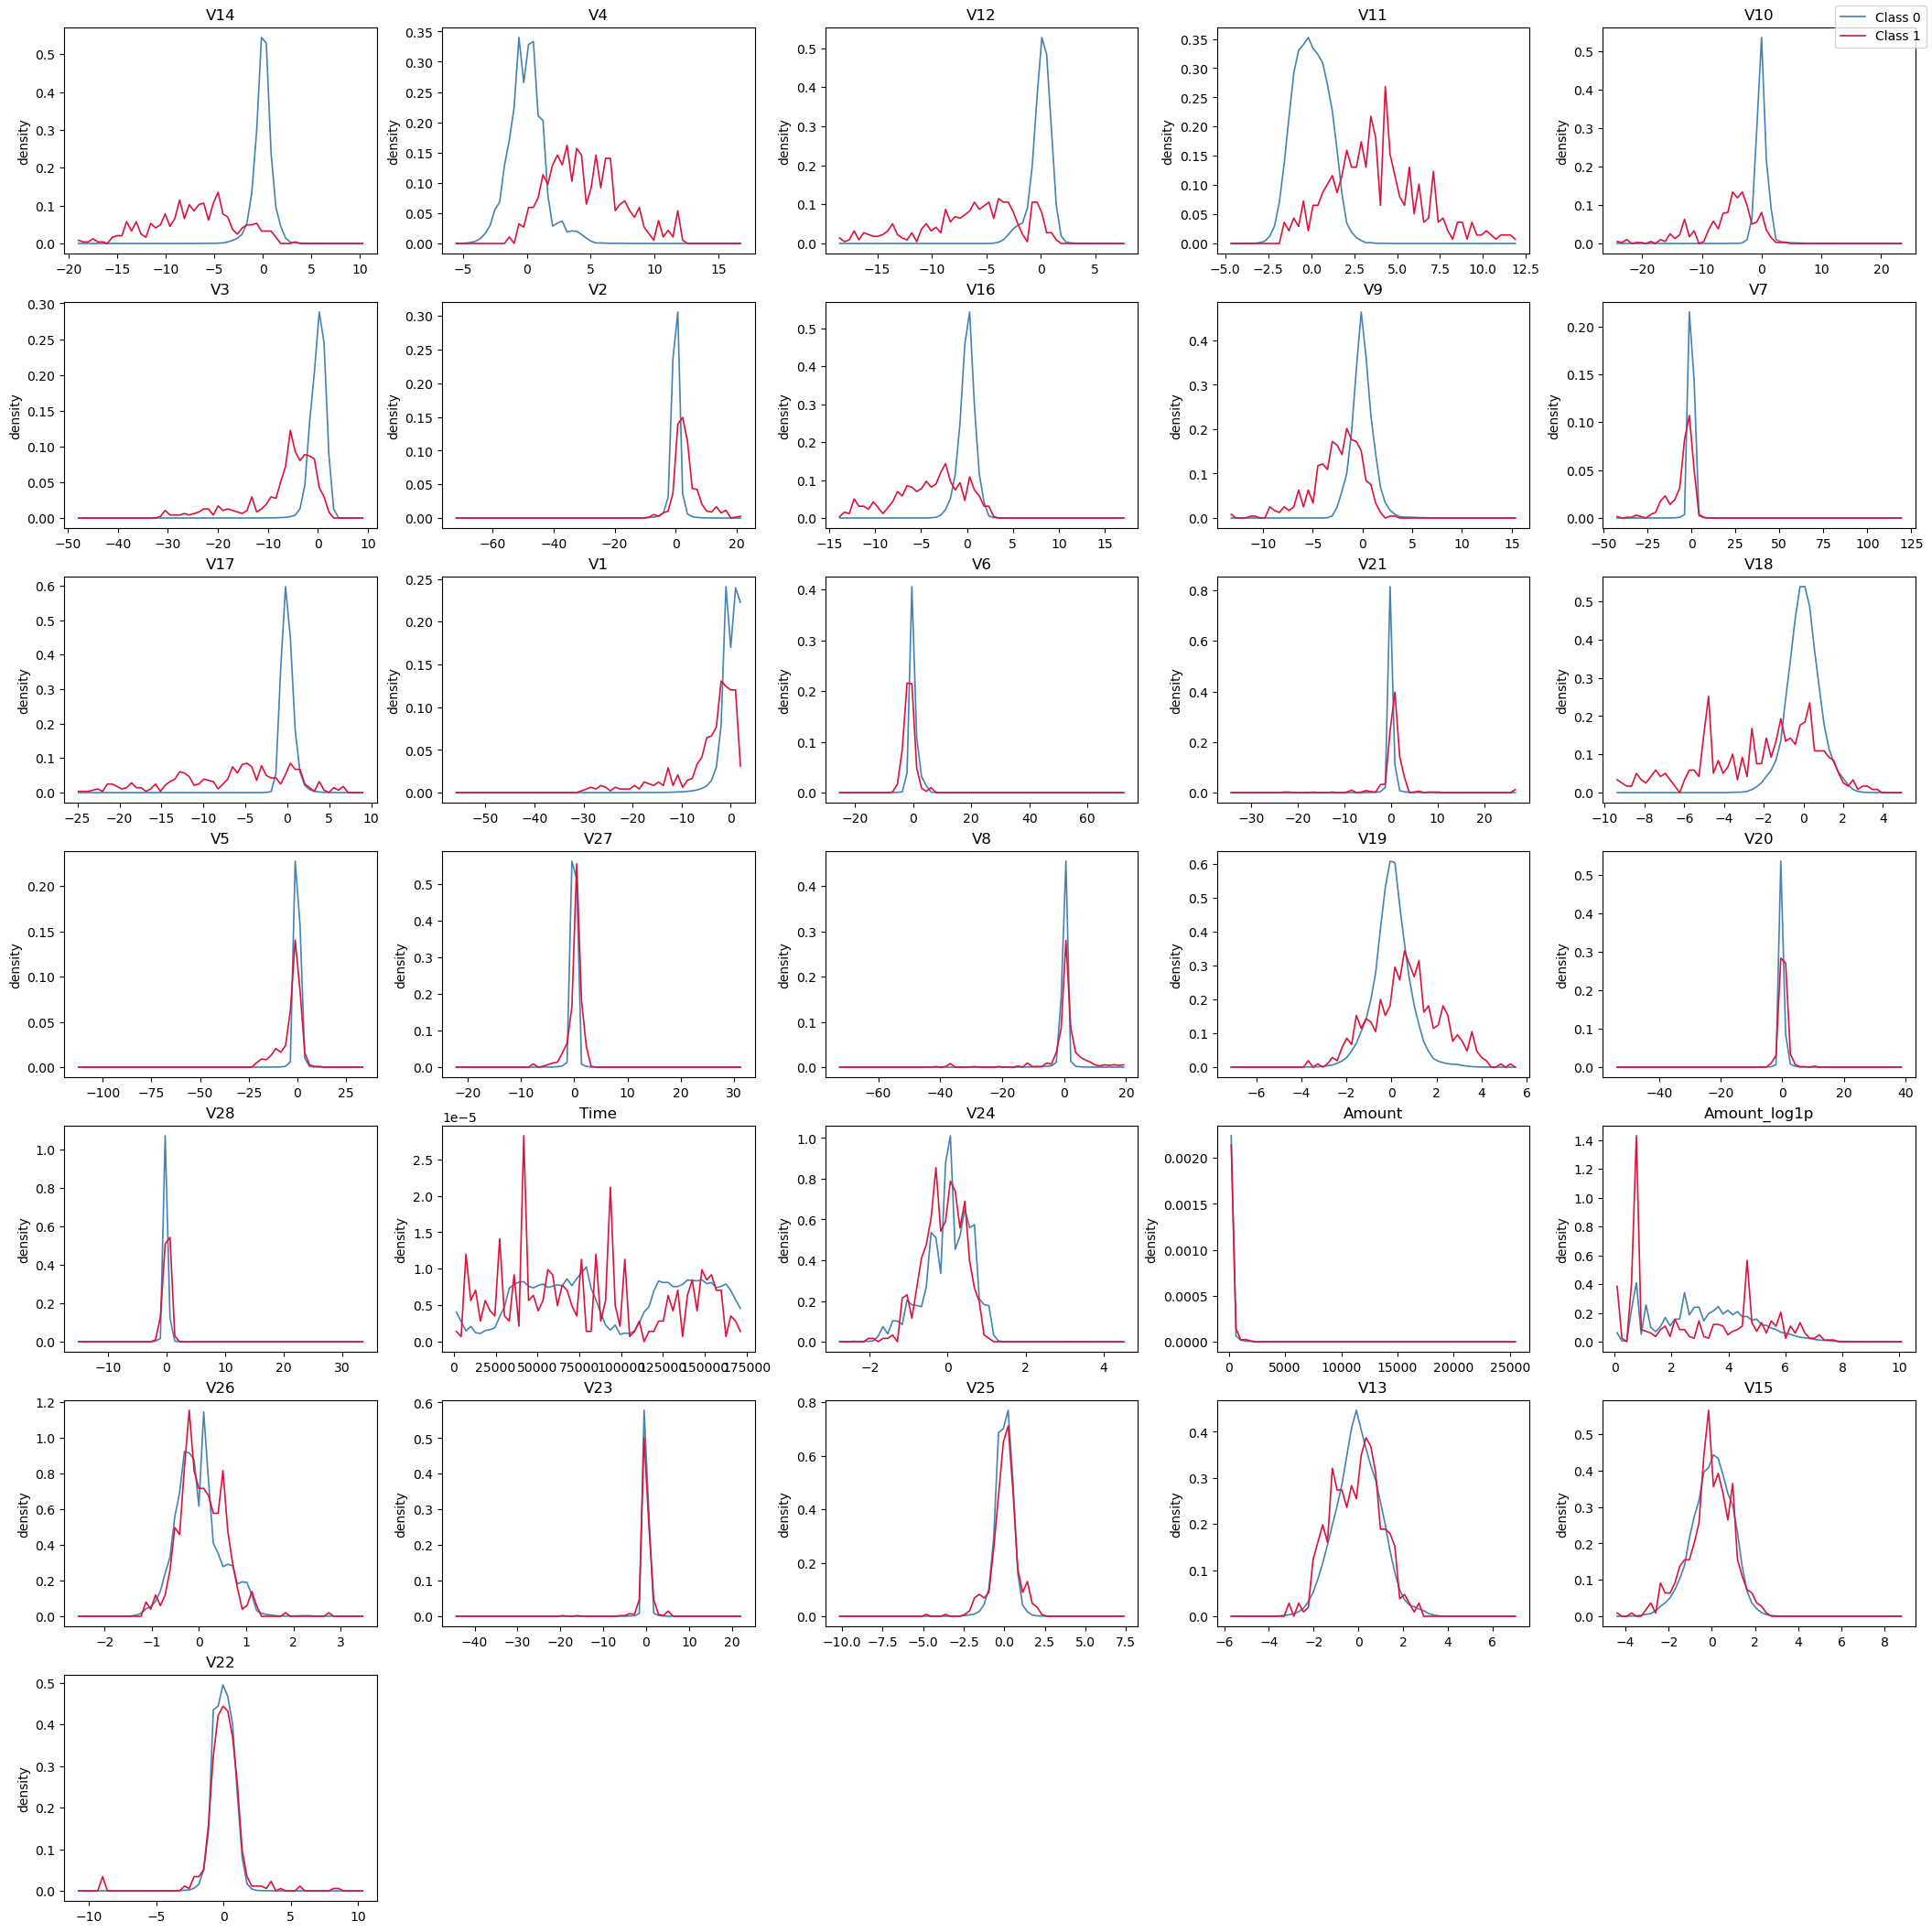

In [80]:
# 4) Связь каждого признака с Class

from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_classif

cols = feature_cols.copy()
if "Amount_log1p" in df.columns and "Amount_log1p" not in cols:
    cols.append("Amount_log1p")

X = df[cols].apply(pd.to_numeric, errors="coerce")
y = df["Class"].astype(int).to_numpy()

rows = []
for col in cols:
    x = X[col].to_numpy()
    mask = ~np.isnan(x)

    # AUC по одной фиче; направление неважно -> symmetrized AUC
    auc = roc_auc_score(y[mask], x[mask])
    auc = max(auc, 1 - auc)

    ks = np.nan
    if ks_2samp is not None:
        x0 = x[(y == 0) & mask]
        x1 = x[(y == 1) & mask]
        ks = float(ks_2samp(x0, x1).statistic)

    rows.append({"feature": col, "auc": float(auc), "ks": ks})

from IPython.display import display

rank_df = pd.DataFrame(rows).sort_values(["auc", "ks"], ascending=False)
print("Top features by AUC/KS")
display(rank_df.head(15))

# MI на очень большом N может быть медленным -> считаем приближённо на стратифицированной выборке
if mutual_info_classif is not None:
    fraud_idx = df.index[df["Class"] == 1]
    nonfraud_idx = df.index[df["Class"] == 0]

    n_nonfraud = min(50_000, len(nonfraud_idx))
    nonfraud_sample_idx = nonfraud_idx.to_series().sample(n=n_nonfraud, random_state=42).values
    mi_idx = np.concatenate([fraud_idx.values, nonfraud_sample_idx])

    X_mi = X.loc[mi_idx].fillna(X.median(numeric_only=True))
    y_mi = df.loc[mi_idx, "Class"].astype(int).to_numpy()

    mi_vals = mutual_info_classif(X_mi, y_mi, random_state=42, discrete_features=False)
    mi_df = pd.DataFrame({"feature": cols, "mi_approx": mi_vals})
    rank_df = rank_df.merge(mi_df, on="feature", how="left").sort_values(
        ["auc", "ks", "mi_approx"], ascending=False
    )

print("Top features (final ranking; MI present if computed)")
display(rank_df.head(15))

# Плотности по классам для всех фич (в порядке rank_df: от самых «связанных» к менее «связанным»)
plot_features = rank_df["feature"].tolist()

n_cols = 5
n_rows = int(np.ceil(len(plot_features) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.0), constrained_layout=True
)
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_features):
    x = X[col].to_numpy()
    mask = ~np.isnan(x)
    edges = np.histogram_bin_edges(x[mask], bins=60)

    x0 = x[(y == 0) & mask]
    x1 = x[(y == 1) & mask]

    h0, _ = np.histogram(x0, bins=edges, density=True)
    h1, _ = np.histogram(x1, bins=edges, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    ax.plot(centers, h0, label="Class 0", color="steelblue", linewidth=1.2)
    ax.plot(centers, h1, label="Class 1", color="crimson", linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel("density")

for ax in axes[len(plot_features):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.show()

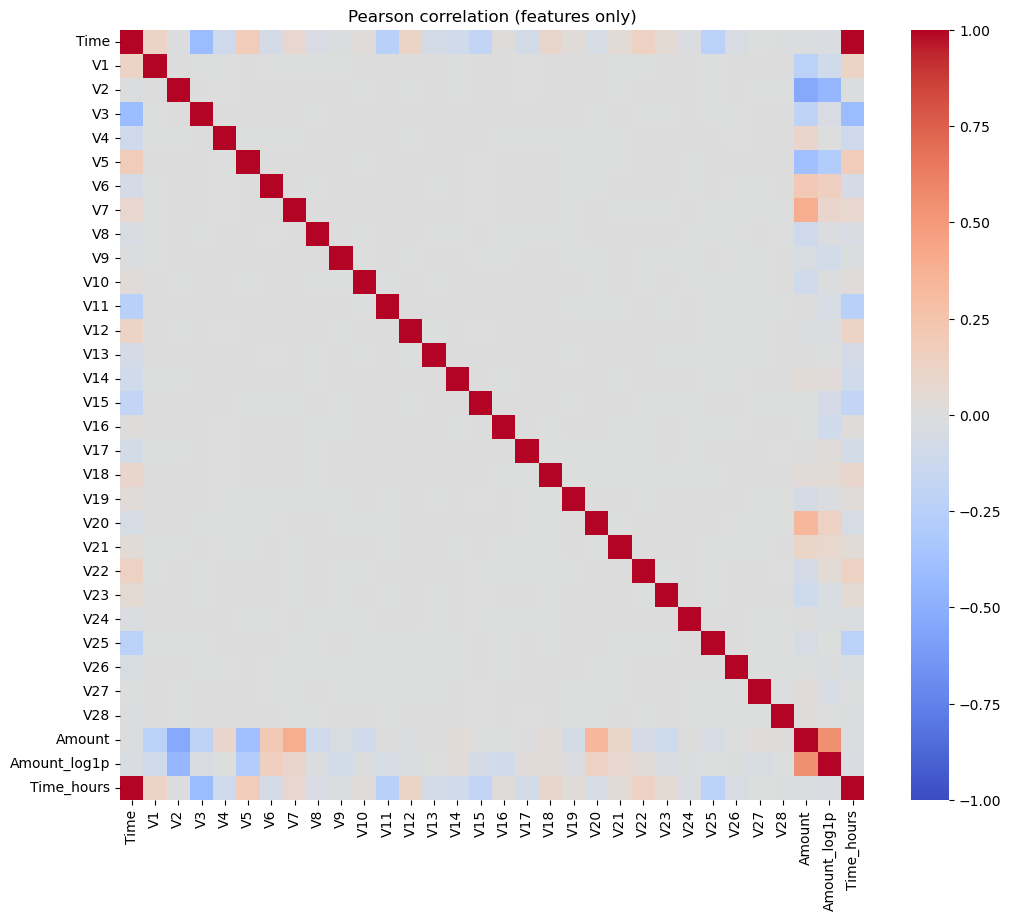

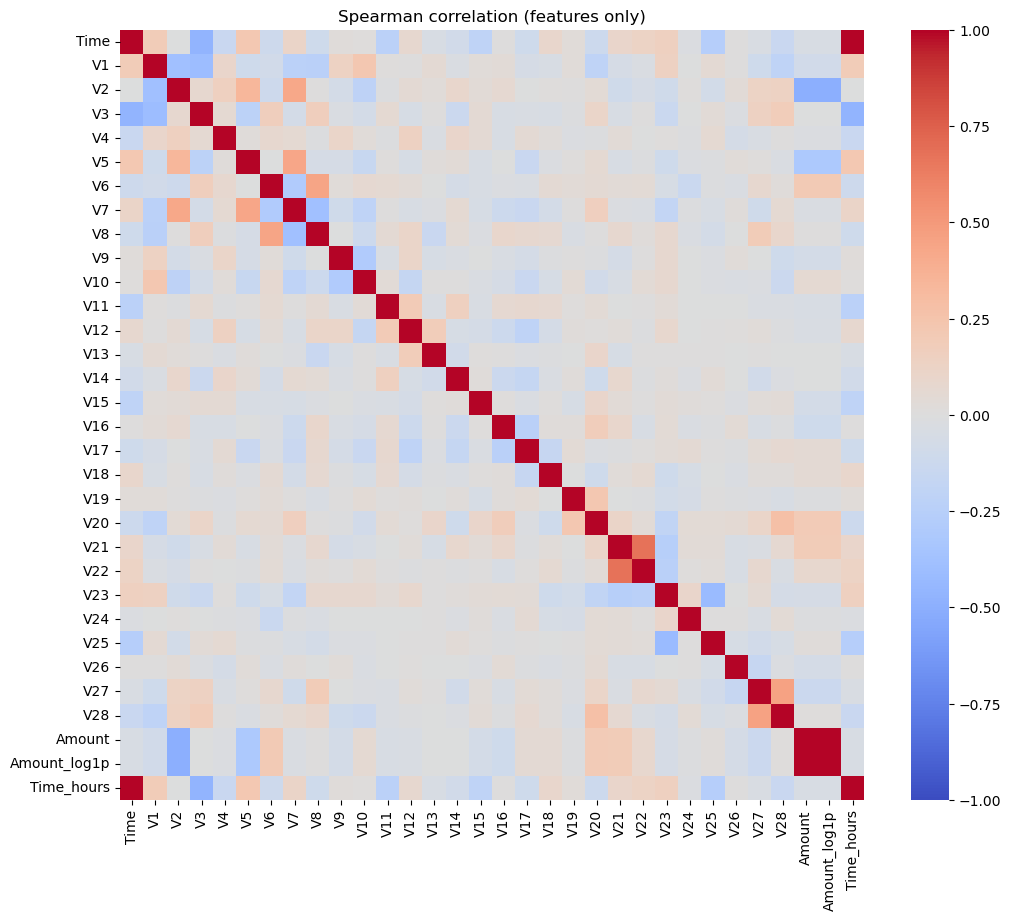

Top |Pearson corr| pairs
Time          Time_hours      1.000000
Amount        Amount_log1p    0.552005
              V2              0.531409
Amount_log1p  V2              0.450317
Time_hours    V3              0.419618
Time          V3              0.419618
Amount        V7              0.397311
              V5              0.386356
              V20             0.339403
Amount_log1p  V5              0.286189
Time_hours    V11             0.247689
Time          V11             0.247689
Time_hours    V25             0.233083
Time          V25             0.233083
Amount        V1              0.227709
              V6              0.215981
              V3              0.210880
Time_hours    V15             0.183453
Time          V15             0.183453
              V5              0.173072
dtype: float64

Top |Spearman corr| pairs
Amount        Amount_log1p    1.000000
Time          Time_hours      1.000000
V21           V22             0.676718
Amount        V2              0.5020

In [81]:
# 5) Связи между признаками: корреляции + топ пар

X_feat = df.drop(columns=["Class"]).apply(pd.to_numeric, errors="coerce")

corr_p = X_feat.corr(method="pearson")
corr_s = X_feat.corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_p, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation (features only)")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_s, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation (features only)")
plt.show()

def top_abs_corr(corr: pd.DataFrame, k: int = 25) -> pd.Series:
    c = corr.copy()
    np.fill_diagonal(c.values, np.nan)
    s = c.abs().unstack().dropna().sort_values(ascending=False)
    s = s[~s.index.map(lambda t: t[0] > t[1])]
    return s.head(k)

print("Top |Pearson corr| pairs")
print(top_abs_corr(corr_p, k=20))

print("\nTop |Spearman corr| pairs")
print(top_abs_corr(corr_s, k=20))

## EDA

- **Данные и цель**
  - **284 807** транзакций, fraud (`Class=1`) — **492** (≈ **0.173%**): сильный дисбаланс классов.
  - Признаки: `Time`, `Amount` и `V1..V28` (PCA‑компоненты; бизнес‑интерпретация ограничена).

- **Распределения и выбросы**
  - `V1..V28`: в целом **сцентрированы около 0**, но почти везде есть **хвосты и редкие экстремальные значения** (по boxenplot).
  - `Amount`: **тяжёлый правый хвост** и редкие большие суммы (выраженные выбросы).
  - `Amount_log1p`: лог‑преобразование **сжимает хвост** и делает распределение стабильнее для анализа, хотя выбросы остаются.
  - `Time`: широкий диапазон без “аномальных” выбросов, но распределение неоднородно.

- **Связь “фича ↔ Class”**
  - По ROC‑AUC/KS/MI лидируют PCA‑компоненты: **`V14` (~0.95 AUC)**, затем **`V4`, `V12`, `V11`, `V10`**, далее **`V3`, `V2`, `V16`, `V9`, `V7`, `V17`**.
  - На графиках плотностей для топ‑фич виден **явный сдвиг распределений** `Class=0` vs `Class=1` → основной сигнал о fraud “зашит” в `V*`.
  - `Time`/`Amount` (и `Amount_log1p`) не в лидерах по одиночным метрикам → сами по себе **слабее разделяют** fraud/non‑fraud, но могут помогать в комбинации в модели.

- **Временная динамика (графики по бинам)**
  - Объём транзакций **неравномерен** во времени (есть провалы/пики активности).
  - Fraud‑rate имеет **резкие пики** на отдельных интервалах; после сглаживания заметен **устойчивый “горб”** примерно в середине окна наблюдения → возможны “окна риска”.
  - Практический вывод: при валидации стоит проверить **time‑based split** или учитывать `Time`‑фичи/биннинг.

- **Связи между признаками (корреляции)**
  - Корреляции между `V*` в целом **невысокие** (ожидаемо для PCA), но есть **умеренные пары** (напр. Spearman `V21–V22` заметно выше остальных; также видны `V27–V28` и др.).
  - `Amount` и `Amount_log1p` **монотонно связаны** (Spearman≈1) (ожидаемо), плюс умеренные связи `Amount` с некоторыми `V*`.

- **Что это значит для моделирования**
  - Нужны подходы под дисбаланс: `class_weight`, подбор порога; метрики — **PR‑AUC/recall при заданной precision**.
  - В baseline‑модели разумно использовать **все признаки**, но ожидать основной вклад от **`V14/V4/V12/V11/V10`** и др.
  - `Amount_log1p` полезен для устойчивости из‑за heavy‑tail у `Amount`.